In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

sys.path.append(str(PROJECT_ROOT / "src"))
from utils import get_attacker_ablations, get_defender_ablations

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

MODEL_BLOCKS = 4
ATTACKER_LABELS = [s["name"] for s in get_attacker_ablations(MODEL_BLOCKS)]
DEFENDER_LABELS = [s["name"] for s in get_defender_ablations(MODEL_BLOCKS)]

In [2]:
def plot_utility_evolution(csv_paths, labels, size):

    """
    Creates a line plot comparing the Relative Loss over the epochs.
    """
    
    plt.figure(figsize=(10, 6))
    
    colors = ['#1f77b4', '#d62728']
    
    for path, label, color in zip(csv_paths, labels, colors):
        if not os.path.exists(path):
            print(f"⚠️ Cannot find file: {path}")
            continue
        
        df = pd.read_csv(path, sep=';')
        df.columns = df.columns.str.strip()
        df_eq = df[df['Equilibrium_Num'] == 1].sort_values('Epoch')
        
        plt.plot(df_eq['Epoch'], df_eq['Relative_Loss'], marker='o', linewidth=2, color=color, label=label)
        
    plt.title('Evolution of Relative Loss per Epoch', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Relative Loss', fontsize=12)
    plt.xticks(sorted(df_eq['Epoch'].unique()) if 'df_eq' in locals() and not df_eq.empty else range(1, 21), rotation=45)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.savefig(f'../../output/figures/nash_plots/utility_{size}x{size}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
def plot_strategies_heatmap(csv_path, epsilon_label, size, attacker_labels=None, defender_labels=None):
    """
    Creates two separate heatmaps (Attacker and Defender) to visualize how the probabilities
    of choosing each network change over the epochs.
    """
        
    df = pd.read_csv(csv_path, sep=';')
    df.columns = df.columns.str.strip()
    df_eq = df[df['Equilibrium_Num'] == 1].sort_values('Epoch')
    
    cols_A = [c for c in df_eq.columns if c.startswith('A')]
    cols_D = [c for c in df_eq.columns if c.startswith('D')]
    
    attacker_labels = [f"A{i+1}" for i in range(len(cols_A))]
    defender_labels = [f"D{i+1}" for i in range(len(cols_D))]
    
    data_A = df_eq[cols_A].values.T
    data_D = df_eq[cols_D].values.T
    
    # Calculate base width based on epochs
    fig_width = max(14, 0.6 * len(df_eq))
    
    # FIGURE 1: ATTACKER
    fig_h_A = max(5, 0.35 * len(cols_A))
    figA, axA = plt.subplots(figsize=(fig_width, fig_h_A))
    
    sns.heatmap(data_A, cmap="Reds", ax=axA, vmin=0, vmax=1,
                xticklabels=df_eq['Epoch'], yticklabels=attacker_labels, 
                annot=True, fmt=".2f", annot_kws={"size": 9},
                cbar_kws={'label': 'Probability'})
    
    for text in axA.texts:
        if text.get_text():
            val = float(text.get_text())
            if val > 0.7:
                text.set_color("#EBEBEB")  
            else:
                text.set_color("#333333")  

    axA.invert_yaxis()
    axA.set_title(f"Evolution of Attacker Strategies (Epsilon = {epsilon_label})", fontsize=14, fontweight='bold')
    axA.set_xlabel('Epoch')
    axA.set_ylabel('Generator (Attacker)')
    axA.tick_params(axis='y', labelsize=9)
    
    figA.tight_layout()
    figA.savefig(f'../../output/figures/nash_plots/strategies_attacker_{size}x{size}_eps_{epsilon_label}.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(figA)  # Free memory
    
    # FIGURE 2: DEFENDER
    fig_h_D = max(5, 0.35 * len(cols_D))
    figD, axD = plt.subplots(figsize=(fig_width, fig_h_D))
    
    sns.heatmap(data_D, cmap="Blues", ax=axD, vmin=0, vmax=1,
                xticklabels=df_eq['Epoch'], yticklabels=defender_labels, 
                annot=True, fmt=".2f", annot_kws={"size": 9},
                cbar_kws={'label': 'Probability'})
                
    for text in axD.texts:
        if text.get_text():
            val = float(text.get_text())
            if val > 0.7:
                text.set_color("#EBEBEB")  
            else:
                text.set_color("#333333") 

    axD.invert_yaxis()
    axD.set_title(f"Evolution of Defender Strategies (Epsilon = {epsilon_label})", fontsize=14, fontweight='bold')
    axD.set_xlabel('Epoch')
    axD.set_ylabel('Classifier (Defender)')
    axD.tick_params(axis='y', labelsize=9)
    
    figD.tight_layout()
    figD.savefig(f'../../output/figures/nash_plots/strategies_defender_{size}x{size}_eps_{epsilon_label}.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(figD)  # Free memory

Generating Utility Function Plot for 10 strategies...

Generating Heatmaps...


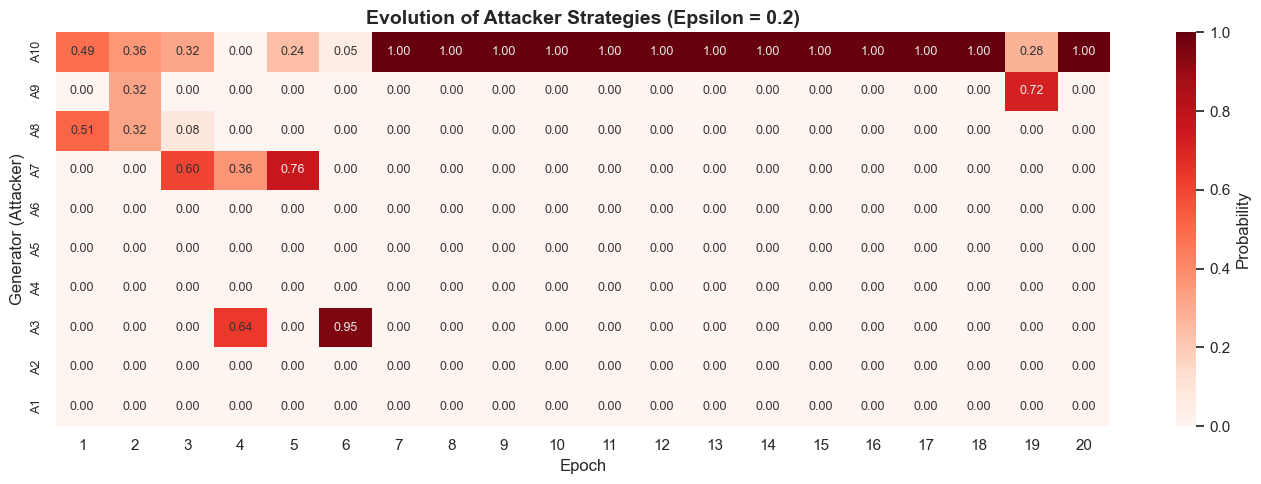

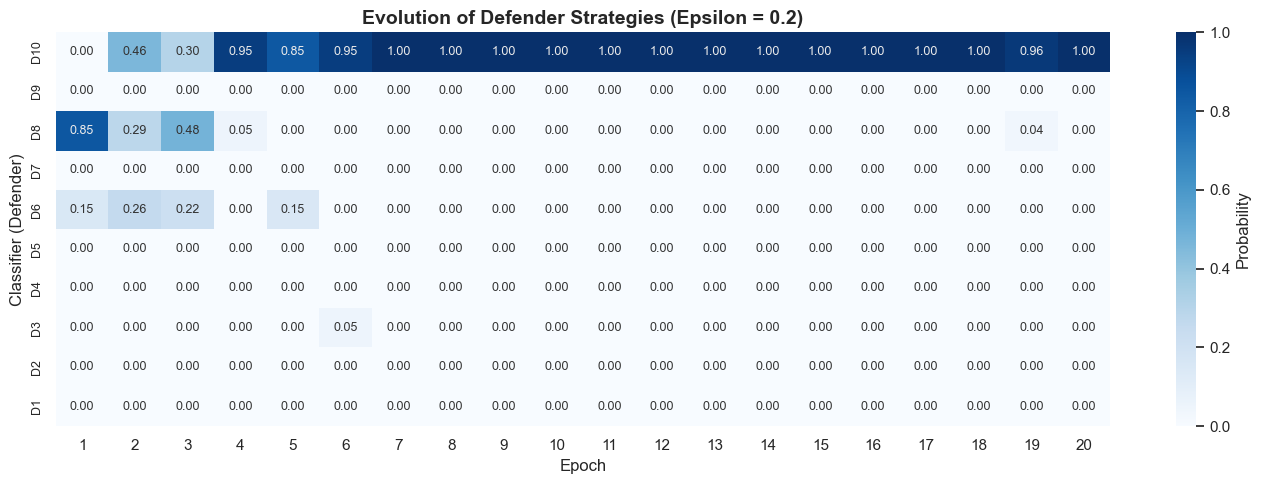

In [12]:
# EXECUTION OF VISUALIZATIONS

size = 10
eps = 0.2

file = f'../../output/nash_equilibria/nash_{size}x{size}_eps_{eps}/nash_{size}x{size}_eps_{eps}.csv'

df_preview = pd.read_csv(file, sep=';')
df_preview.columns = df_preview.columns.str.strip()
strategy_count = len([c for c in df_preview.columns if c.startswith('A')])
print(f"Generating Utility Function Plot for {strategy_count} strategies...")
# plot_utility_evolution([file], [f'Epsilon {eps}'], size=size)

print("\nGenerating Heatmaps...")
plot_strategies_heatmap(file, f'{eps}', size=size, attacker_labels=ATTACKER_LABELS, defender_labels=DEFENDER_LABELS)